# Unified model evaluation notebook

Этот ноутбук:

- находит все модели `*.joblib` и `*.cbm` в указанных папках;
- загружает датасет и повторяет ту же подготовку, что была в исходных ноутбуках;
- для **каждой** модели автоматически определяет целевой столбец по имени файла:
  - `..._1s.cbm` → `dead_in_1`
  - `..._5s.joblib` → `dead_in_5`
  - `..._10s.cbm` → `dead_in_10`
- воспроизводит сплит по той же логике, что использовалась при обучении;
- считает метрики на test-части;
- строит ROC и PR-кривые;
- собирает сравнительную таблицу по всем моделям.

> Важно: target теперь не фиксирован в одном столбце. Он берётся из имени модели, чтобы модель на `x` секунд всегда оценивалась на `dead_in_{x}`.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import joblib
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from pandas.api.types import is_numeric_dtype

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
# =========================
# Paths and configuration
# =========================

# Adjust these paths to your environment.
DATA_PATH = Path("../full_dataset.csv")
HERO_NAMES_PATH = Path("../heroNames.json")

# Where to look for model files.
MODEL_SEARCH_ROOTS = [
    Path("artifacts"),
]

TARGET_PREFIX = "dead_in_"
MATCH_ID_COL = "match_id"
TIME_COL = "game_time"

HERO_COLS = [
    "hero_id",
    "enemy_1_name",
    "enemy_2_name",
    "enemy_3_name",
    "enemy_4_name",
    "enemy_5_name",
]

RANDOM_STATE = 120
TEST_SIZE = 0.15
VAL_SIZE = 0.15

THRESHOLD_GRID = np.linspace(0.05, 0.95, 181)

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"
assert HERO_NAMES_PATH.exists(), f"heroNames.json not found: {HERO_NAMES_PATH.resolve()}"


In [3]:
def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")

    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if suffix == ".feather":
        return pd.read_feather(path)

    raise ValueError(f"Unsupported dataset format: {suffix}")


def transform_name_to_id(df: pd.DataFrame, hero_cols: list[str]) -> pd.DataFrame:
    with open(HERO_NAMES_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = df.copy()
    for col in hero_cols:
        if col not in df.columns:
            continue
        if is_numeric_dtype(df[col]):
            continue
        df[col] = df[col].apply(lambda x: data.get(x, pd.NA))
        df[col] = df[col].astype("Int64")

    return df


def sort_enemies(df: pd.DataFrame) -> pd.DataFrame:
    """
    The same helper as in the training notebooks:
    sorts enemy-related columns by last_seen_distance.
    """
    df = df.copy()

    en = 5
    enemy_names_cols = [f"enemy_{i}_name" for i in range(1, en + 1)]
    enemy_x_cols = [f"enemy_{i}_last_seen_x" for i in range(1, en + 1)]
    enemy_y_cols = [f"enemy_{i}_last_seen_y" for i in range(1, en + 1)]
    enemy_square_cols = [f"enemy_{i}_last_seen_sqare" for i in range(1, en + 1)]
    enemy_distance_cols = [f"enemy_{i}_last_seen_distance" for i in range(1, en + 1)]
    enemy_time_cols = [f"enemy_{i}_last_seen_time" for i in range(1, en + 1)]

    needed = (
        enemy_names_cols
        + enemy_x_cols
        + enemy_y_cols
        + enemy_square_cols
        + enemy_distance_cols
        + enemy_time_cols
    )
    missing = [c for c in needed if c not in df.columns]
    if missing:
        # In case the dataset version does not contain these columns.
        return df

    enemy_names = df[enemy_names_cols].to_numpy()
    enemy_x = df[enemy_x_cols].to_numpy()
    enemy_y = df[enemy_y_cols].to_numpy()
    enemy_square = df[enemy_square_cols].to_numpy()
    enemy_distance = df[enemy_distance_cols].to_numpy()
    enemy_time = df[enemy_time_cols].to_numpy()

    order = np.argsort(enemy_distance, axis=1)

    df[enemy_names_cols] = np.take_along_axis(enemy_names, order, axis=1)
    df[enemy_x_cols] = np.take_along_axis(enemy_x, order, axis=1)
    df[enemy_y_cols] = np.take_along_axis(enemy_y, order, axis=1)
    df[enemy_square_cols] = np.take_along_axis(enemy_square, order, axis=1)
    df[enemy_distance_cols] = np.take_along_axis(enemy_distance, order, axis=1)
    df[enemy_time_cols] = np.take_along_axis(enemy_time, order, axis=1)

    return df


def load_and_prepare_dataset() -> pd.DataFrame:
    df = load_data(DATA_PATH)
    print("Raw shape:", df.shape)

    assert MATCH_ID_COL in df.columns, f"No group column: {MATCH_ID_COL}"
    print("Available target columns:", sorted([c for c in df.columns if c.startswith(TARGET_PREFIX)]))

    df = df.pipe(transform_name_to_id, HERO_COLS).pipe(sort_enemies).dropna().reset_index(drop=True)
    print("Prepared shape:", df.shape)
    return df


df = load_and_prepare_dataset()
df.head()


Raw shape: (714600, 106)
Available target columns: ['dead_in_1', 'dead_in_10', 'dead_in_15', 'dead_in_20', 'dead_in_5']
Prepared shape: (714528, 106)


,id,match_id,game_time,is_day,is_radiant,radiant_score,dire_score,hero_id,level,kills,deaths,assists,last_hits,denies,gold,net_worth,x,y,square,xp,health,mana,max_health,max_mana,agility,intellect,strength,magical_resistance,armor,bkb_cooldown,movespeed,ability1_level,ability1_castrange,ability1_manacost,ability1_cooldown,ability2_level,ability2_castrange,ability2_manacost,ability2_cooldown,ability3_level,ability3_castrange,ability3_manacost,ability3_cooldown,ability4_level,ability4_castrange,ability4_manacost,ability4_cooldown,nearest_ally_tower_distance,nearest_enemy_tower_distance,slot_1_id,enemy_1_name,enemy_1_last_seen_x,enemy_1_last_seen_y,enemy_1_last_seen_sqare,enemy_1_last_seen_distance,enemy_1_last_seen_time,slot_2_id,enemy_2_name,enemy_2_last_seen_x,enemy_2_last_seen_y,enemy_2_last_seen_sqare,enemy_2_last_seen_distance,enemy_2_last_seen_time,slot_3_id,enemy_3_name,enemy_3_last_seen_x,enemy_3_last_seen_y,enemy_3_last_seen_sqare,enemy_3_last_seen_distance,enemy_3_last_seen_time,slot_4_id,enemy_4_name,enemy_4_last_seen_x,enemy_4_last_seen_y,enemy_4_last_seen_sqare,enemy_4_last_seen_distance,enemy_4_last_seen_time,slot_5_id,enemy_5_name,enemy_5_last_seen_x,enemy_5_last_seen_y,enemy_5_last_seen_sqare,enemy_5_last_seen_distance,enemy_5_last_seen_time,item_black_king_bar,item_blink,item_force_staff,item_basher,item_abyssal_blade,item_nullifier,item_lotus_orb,item_travel_boots,item_tpscroll,item_phase_boots,item_silver_edge,item_heart,item_sphere,item_manta,item_blade_mail,item_aeon_disk,item_pipe,dead_in_1,dead_in_5,dead_in_10,dead_in_15,dead_in_20
0,1,8766917279,43,1,1,0,0,86,1,0,0,0,0,0,185,735,5040,-5769,186,14,632,363,632,363,23,24,21,27,4,0,305,0,0,0,0,1,800,110,16,0,0,0,0,0,0,0,0,5421,449,1,29,5570,-5893,155,544,0,2,136,5563,-6078,155,607,0,3,17,-490,209,528,8145,0,4,41,6893,6459,925,12368,131,5,14,-5832,5438,838,15615,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,8766917279,65,1,1,0,0,129,1,0,0,0,0,0,218,758,-7404,5197,803,104,626,327,626,327,20,21,23,27,2,0,310,0,0,0,0,1,0,90,16,0,0,0,0,1,0,0,0,6201,2091,1,14,-6005,4985,806,1293,0,2,17,-1144,-178,495,8201,0,3,41,6893,6459,925,14206,153,4,29,5324,-5649,187,16673,0,5,136,5565,-5653,187,16857,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,3,8766917279,68,1,1,0,0,129,1,0,0,0,0,0,222,762,-7275,5072,803,104,626,327,626,327,20,21,23,27,2,0,310,0,0,0,0,1,0,90,16,0,0,0,0,1,0,0,0,5982,2412,1,14,-6005,4985,806,1507,3,2,17,-1561,-381,494,8039,0,3,41,6893,6459,925,14477,156,4,29,5305,-5740,187,16738,0,5,136,5520,-5491,187,16746,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,4,8766917279,77,1,1,0,0,129,1,0,0,0,0,1,236,746,-7392,3716,707,104,626,327,626,327,20,21,23,27,2,0,310,0,0,0,0,1,0,90,16,0,0,0,0,1,0,0,0,4820,2336,1,41,-7148,4329,772,678,0,2,14,-6040,4597,774,1740,5,3,17,-1654,-804,462,7532,6,4,136,5294,-5614,187,15977,1,5,29,5171,-5985,154,16101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
4,5,8766917279,80,1,1,0,0,129,1,0,0,0,0,1,240,750,-6546,3526,709,104,626,327,626,327,20,21,23,27,2,0,310,0,0,0,0,1,0,90,16,0,0,0,0,1,0,0,0,4614,1900,1,14,-6416,3891,741,217,0,2,41,-6794,3661,708,234,0,3,17,-1266,-152,494,6582,0,4,136,5294,-5614,187,15112,4,5,29,5275,-6005,154,15342,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1


In [4]:
def split_by_groups(
    df: pd.DataFrame,
    group_col: str,
    test_size: float = TEST_SIZE,
    val_size: float = VAL_SIZE,
    random_state: int = RANDOM_STATE,
):
    """
    Split used in final_catboost.ipynb:
    shuffle unique groups and cut them into train/val/test.
    """
    if not (0 < test_size < 1 and 0 < val_size < 1):
        raise ValueError("test_size and val_size must be in (0, 1)")
    if test_size + val_size >= 1:
        raise ValueError("test_size + val_size must be < 1")

    groups = df[group_col].drop_duplicates().to_numpy().copy()
    rng = np.random.default_rng(random_state)
    rng.shuffle(groups)

    n_groups = len(groups)
    n_test = int(round(n_groups * test_size))
    n_val = int(round(n_groups * val_size))

    test_groups = set(groups[:n_test])
    val_groups = set(groups[n_test:n_test + n_val])
    train_groups = set(groups[n_test + n_val:])

    train_df = df[df[group_col].isin(train_groups)].copy()
    val_df = df[df[group_col].isin(val_groups)].copy()
    test_df = df[df[group_col].isin(test_groups)].copy()

    return train_df, val_df, test_df


def group_train_val_test_split(
    df: pd.DataFrame,
    group_col: str,
    test_size: float = TEST_SIZE,
    val_size: float = VAL_SIZE,
    random_state: int = RANDOM_STATE,
):
    """
    Split used in logreg.ipynb:
    first test via GroupShuffleSplit, then validation from the remaining part.
    """
    dummy_y = np.zeros(len(df), dtype=int)

    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(gss1.split(df, dummy_y, groups=df[group_col]))

    df_train_val = df.iloc[train_val_idx].copy()
    df_test = df.iloc[test_idx].copy()

    val_ratio_within_train_val = val_size / (1.0 - test_size)

    gss2 = GroupShuffleSplit(
        n_splits=1,
        test_size=val_ratio_within_train_val,
        random_state=random_state,
    )
    dummy_y_train_val = np.zeros(len(df_train_val), dtype=int)
    train_idx, val_idx = next(gss2.split(df_train_val, dummy_y_train_val, groups=df_train_val[group_col]))

    df_train = df_train_val.iloc[train_idx].copy()
    df_val = df_train_val.iloc[val_idx].copy()

    return df_train, df_val, df_test


def evaluate_probabilities(y_true, y_proba, threshold: float = 0.5) -> dict:
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "logloss": log_loss(y_true, y_proba, labels=[0, 1]),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def choose_best_threshold_grid(y_true, y_proba, threshold_grid=THRESHOLD_GRID) -> tuple[float, pd.DataFrame]:
    rows = []
    for t in threshold_grid:
        y_pred = (np.asarray(y_proba) >= t).astype(int)
        rows.append(
            {
                "threshold": float(t),
                "accuracy": accuracy_score(y_true, y_pred),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    thr_df = pd.DataFrame(rows)
    best_row = thr_df.sort_values(["f1", "precision", "recall"], ascending=[False, False, False]).iloc[0]
    return float(best_row["threshold"]), thr_df


def choose_best_threshold_prcurve(y_true, y_proba) -> tuple[float, pd.DataFrame]:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    if thresholds.size == 0:
        thr_df = pd.DataFrame([{"threshold": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}])
        return 0.5, thr_df

    f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
    thr_df = pd.DataFrame(
        {
            "threshold": thresholds.astype(float),
            "precision": precision[:-1].astype(float),
            "recall": recall[:-1].astype(float),
            "f1": f1_scores.astype(float),
        }
    )
    best_idx = int(np.argmax(f1_scores))
    return float(thresholds[best_idx]), thr_df


def plot_roc_pr_curves(y_true, y_proba, title_prefix: str = "Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", label="random baseline")
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")
    axes[0].set_title(f"{title_prefix}: ROC curve")
    axes[0].legend()

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    axes[1].plot(recall, precision, label=f"PR-AUC = {ap:.4f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix}: PR curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [5]:
# Train/test feature sets that match both notebooks

all_target_cols = [c for c in df.columns if c.startswith(TARGET_PREFIX)]

# Technical columns and all target columns are excluded from features.
cols_to_drop = {
    MATCH_ID_COL,
    "id",
    "slot_1_id",
    "slot_2_id",
    "slot_3_id",
    "slot_4_id",
    "slot_5_id",
    *all_target_cols,
}

feature_cols = [c for c in df.columns if c not in cols_to_drop]
categorical_cols = [c for c in HERO_COLS if c in df.columns]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("Feature columns:", len(feature_cols))
print("Categorical columns:", categorical_cols)
print("Numeric columns:", len(numeric_cols))
print("Target columns:", all_target_cols)


Feature columns: 94
Categorical columns: ['hero_id', 'enemy_1_name', 'enemy_2_name', 'enemy_3_name', 'enemy_4_name', 'enemy_5_name']
Numeric columns: 88
Target columns: ['dead_in_1', 'dead_in_5', 'dead_in_10', 'dead_in_15', 'dead_in_20']


In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

In [7]:
def infer_target_from_model_path(model_path: Path) -> tuple[str, int]:
    """
    Extract x from a filename like ..._{x}s.cbm or ..._{x}s.joblib,
    and map it to dead_in_{x}.
    """
    m = re.search(r"_(\d+)s$", model_path.stem)
    if not m:
        raise ValueError(
            f"Cannot infer target from model filename: {model_path.name}. "
            "Expected suffix like '_1s', '_5s', '_10s'."
        )
    seconds = int(m.group(1))
    return f"dead_in_{seconds}", seconds


def discover_model_files(roots: list[Path]) -> list[Path]:
    files: set[Path] = set()
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        files.update(root.rglob("*.joblib"))
        files.update(root.rglob("*.cbm"))

    def sort_key(p: Path):
        try:
            _, sec = infer_target_from_model_path(p)
        except ValueError:
            sec = 10**9
        return (sec, p.as_posix())

    return sorted(files, key=sort_key)


model_files = discover_model_files(MODEL_SEARCH_ROOTS)
print("Found model files:")
for p in model_files:
    print(" -", p)

assert model_files, "No *.joblib or *.cbm files found. Add the correct folder to MODEL_SEARCH_ROOTS."


Found model files:
 - artifacts/boosting/catboost_dota_model_1s.cbm
 - artifacts/logreg/dota_logreg_pipeline_1s.joblib
 - artifacts/boosting/catboost_dota_model_5s.cbm
 - artifacts/logreg/dota_logreg_pipeline_5s.joblib
 - artifacts/boosting/catboost_dota_model_10s.cbm
 - artifacts/logreg/dota_logreg_pipeline_10s.joblib
 - artifacts/boosting/catboost_dota_model_15s.cbm
 - artifacts/logreg/dota_logreg_pipeline_15s.joblib
 - artifacts/boosting/catboost_dota_model_20s.cbm
 - artifacts/logreg/dota_logreg_pipeline_20s.joblib


In [8]:
def load_model_artifact(model_path: Path):
    suffix = model_path.suffix.lower()
    if suffix == ".joblib":
        return joblib.load(model_path)
    if suffix == ".cbm":
        model = CatBoostClassifier()
        model.load_model(str(model_path))
        return model
    raise ValueError(f"Unsupported model format: {suffix}")


def build_splits_for_model(df: pd.DataFrame, model_path: Path):
    if model_path.suffix.lower() == ".cbm":
        return split_by_groups(df, MATCH_ID_COL, TEST_SIZE, VAL_SIZE, RANDOM_STATE), "manual_group_shuffle", "grid_f1"
    if model_path.suffix.lower() == ".joblib":
        return group_train_val_test_split(df, MATCH_ID_COL, TEST_SIZE, VAL_SIZE, RANDOM_STATE), "group_shuffle_split", "prcurve_f1"
    raise ValueError(f"Unsupported model format: {model_path.suffix}")


def predict_proba_for_model(model, model_path: Path, X: pd.DataFrame) -> np.ndarray:
    if model_path.suffix.lower() == ".cbm":
        pool = Pool(X, cat_features=categorical_cols)
        return model.predict_proba(pool)[:, 1]
    return model.predict_proba(X)[:, 1]


In [9]:
results = []
details = {}

for model_path in model_files:
    target_col, target_seconds = infer_target_from_model_path(model_path)
    if target_col not in df.columns:
        raise KeyError(
            f"Target column '{target_col}' is missing in dataset for model '{model_path.name}'. "
            f"Available target columns: {sorted([c for c in df.columns if c.startswith(TARGET_PREFIX)])}"
        )

    model = load_model_artifact(model_path)
    (df_train, df_val, df_test), split_name, thr_name = build_splits_for_model(df, model_path)

    X_train = df_train[feature_cols].copy()
    y_train = df_train[target_col].astype(int).copy()
    X_val = df_val[feature_cols].copy()
    y_val = df_val[target_col].astype(int).copy()
    X_test = df_test[feature_cols].copy()
    y_test = df_test[target_col].astype(int).copy()

    val_proba = predict_proba_for_model(model, model_path, X_val)
    test_proba = predict_proba_for_model(model, model_path, X_test)

    if model_path.suffix.lower() == ".cbm":
        best_threshold, thr_df = choose_best_threshold_grid(y_val, val_proba)
    else:
        best_threshold, thr_df = choose_best_threshold_prcurve(y_val, val_proba)

    val_metrics = evaluate_probabilities(y_val, val_proba, threshold=best_threshold)
    test_metrics = evaluate_probabilities(y_test, test_proba, threshold=best_threshold)

    model_name = model_path.stem
    model_id = model_path.as_posix()

    results.append(
        {
            "model": model_name,
            "model_id": model_id,
            "file": str(model_path),
            "format": model_path.suffix.lower().lstrip("."),
            "target_col": target_col,
            "target_seconds": target_seconds,
            "split_strategy": split_name,
            "threshold_strategy": thr_name,
            "threshold": best_threshold,
            "train_rows": len(df_train),
            "val_rows": len(df_val),
            "test_rows": len(df_test),
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_logloss": val_metrics["logloss"],
            "test_logloss": test_metrics["logloss"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_brier": test_metrics["brier"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
        }
    )

    details[model_id] = {
        "model_path": model_path,
        "target_col": target_col,
        "target_seconds": target_seconds,
        "display_name": f"{model_name} ({target_col})",
        "threshold": best_threshold,
        "y_test": y_test,
        "test_proba": test_proba,
    }

results_df = pd.DataFrame(results).sort_values(["target_seconds", "format", "model"]).reset_index(drop=True)
results_df


,model,model_id,file,format,target_col,target_seconds,split_strategy,threshold_strategy,threshold,train_rows,val_rows,test_rows,val_roc_auc,val_pr_auc,val_logloss,test_logloss,test_roc_auc,test_pr_auc,test_brier,test_accuracy,test_precision,test_recall,test_f1
0,catboost_dota_model_1s,artifacts/boosting/catboost_dota_model_1s.cbm,artifacts/boosting/catboost_dota_model_1s.cbm,cbm,dead_in_1,1,manual_group_shuffle,grid_f1,0.245000,440147,184038,90343,0.809828,0.439192,0.362936,0.365229,0.806717,0.440010,0.115257,0.772622,0.394239,0.635141,0.486501
1,dota_logreg_pipeline_1s,artifacts/logreg/dota_logreg_pipeline_1s.joblib,artifacts/logreg/dota_logreg_pipeline_1s.joblib,joblib,dead_in_1,1,group_shuffle_split,prcurve_f1,0.520301,527982,93944,92602,0.669436,0.266902,0.649428,0.649152,0.668971,0.264175,0.232079,0.612006,0.250136,0.639926,0.359680
2,catboost_dota_model_5s,artifacts/boosting/catboost_dota_model_5s.cbm,artifacts/boosting/catboost_dota_model_5s.cbm,cbm,dead_in_5,5,manual_group_shuffle,grid_f1,0.335000,440147,184038,90343,0.822187,0.690136,0.481501,0.484114,0.820007,0.688413,0.160161,0.740943,0.591663,0.762101,0.666153
3,dota_logreg_pipeline_5s,artifacts/logreg/dota_logreg_pipeline_5s.joblib,artifacts/logreg/dota_logreg_pipeline_5s.joblib,joblib,dead_in_5,5,group_shuffle_split,prcurve_f1,0.459512,527982,93944,92602,0.678926,0.485898,0.643022,0.642284,0.678216,0.480331,0.227761,0.561835,0.425461,0.817896,0.559747
4,catboost_dota_model_10s,artifacts/boosting/catboost_dota_model_10s.cbm,artifacts/boosting/catboost_dota_model_10s.cbm,cbm,dead_in_10,10,manual_group_shuffle,grid_f1,0.375000,440147,184038,90343,0.806381,0.801266,0.532407,0.534041,0.804698,0.800492,0.180010,0.716835,0.680983,0.833591,0.749599
5,dota_logreg_pipeline_10s,artifacts/logreg/dota_logreg_pipeline_10s.joblib,artifacts/logreg/dota_logreg_pipeline_10s.joblib,joblib,dead_in_10,10,group_shuffle_split,prcurve_f1,0.411738,527982,93944,92602,0.679743,0.656929,0.637178,0.638251,0.676372,0.648750,0.225037,0.602600,0.569532,0.908066,0.700018
6,catboost_dota_model_15s,artifacts/boosting/catboost_dota_model_15s.cbm,artifacts/boosting/catboost_dota_model_15s.cbm,cbm,dead_in_15,15,manual_group_shuffle,grid_f1,0.410000,440147,184038,90343,0.795579,0.881203,0.490220,0.490437,0.794440,0.881044,0.163349,0.744507,0.740373,0.959181,0.835692
7,dota_logreg_pipeline_15s,artifacts/logreg/dota_logreg_pipeline_15s.joblib,artifacts/logreg/dota_logreg_pipeline_15s.joblib,joblib,dead_in_15,15,group_shuffle_split,prcurve_f1,0.014846,527982,93944,92602,0.684811,0.799075,0.622617,0.623889,0.681177,0.792759,0.217992,0.716118,0.705718,0.999476,0.827294
8,catboost_dota_model_20s,artifacts/boosting/catboost_dota_model_20s.cbm,artifacts/boosting/catboost_dota_model_20s.cbm,cbm,dead_in_20,20,manual_group_shuffle,grid_f1,0.475000,440147,184038,90343,0.841172,0.960535,0.296733,0.294405,0.840575,0.960836,0.087297,0.888071,0.886396,0.995278,0.937686
9,dota_logreg_pipeline_20s,artifacts/logreg/dota_logreg_pipeline_20s.joblib,artifacts/logreg/dota_logreg_pipeline_20s.joblib,joblib,dead_in_20,20,group_shuffle_split,prcurve_f1,0.012666,527982,93944,92602,0.741348,0.929435,0.548855,0.548939,0.741610,0.926999,0.183640,0.885758,0.881508,0.999987,0.937017


In [10]:
display(
    results_df.style.format(
        {
            "threshold": "{:.4f}",
            "val_roc_auc": "{:.4f}",
            "val_pr_auc": "{:.4f}",
            "val_logloss": "{:.4f}",
            "test_logloss": "{:.4f}",
            "test_roc_auc": "{:.4f}",
            "test_pr_auc": "{:.4f}",
            "test_brier": "{:.4f}",
            "test_accuracy": "{:.4f}",
            "test_precision": "{:.4f}",
            "test_recall": "{:.4f}",
            "test_f1": "{:.4f}",
        }
    )
)

results_df.to_csv("model_comparison.csv", index=False)
print("Saved: model_comparison.csv")


,model,model_id,file,format,target_col,target_seconds,split_strategy,threshold_strategy,threshold,train_rows,val_rows,test_rows,val_roc_auc,val_pr_auc,val_logloss,test_logloss,test_roc_auc,test_pr_auc,test_brier,test_accuracy,test_precision,test_recall,test_f1
0,catboost_dota_model_1s,artifacts/boosting/catboost_dota_model_1s.cbm,artifacts/boosting/catboost_dota_model_1s.cbm,cbm,dead_in_1,1,manual_group_shuffle,grid_f1,0.2450,440147,184038,90343,0.8098,0.4392,0.3629,0.3652,0.8067,0.4400,0.1153,0.7726,0.3942,0.6351,0.4865
1,dota_logreg_pipeline_1s,artifacts/logreg/dota_logreg_pipeline_1s.joblib,artifacts/logreg/dota_logreg_pipeline_1s.joblib,joblib,dead_in_1,1,group_shuffle_split,prcurve_f1,0.5203,527982,93944,92602,0.6694,0.2669,0.6494,0.6492,0.6690,0.2642,0.2321,0.6120,0.2501,0.6399,0.3597
2,catboost_dota_model_5s,artifacts/boosting/catboost_dota_model_5s.cbm,artifacts/boosting/catboost_dota_model_5s.cbm,cbm,dead_in_5,5,manual_group_shuffle,grid_f1,0.3350,440147,184038,90343,0.8222,0.6901,0.4815,0.4841,0.8200,0.6884,0.1602,0.7409,0.5917,0.7621,0.6662
3,dota_logreg_pipeline_5s,artifacts/logreg/dota_logreg_pipeline_5s.joblib,artifacts/logreg/dota_logreg_pipeline_5s.joblib,joblib,dead_in_5,5,group_shuffle_split,prcurve_f1,0.4595,527982,93944,92602,0.6789,0.4859,0.6430,0.6423,0.6782,0.4803,0.2278,0.5618,0.4255,0.8179,0.5597
4,catboost_dota_model_10s,artifacts/boosting/catboost_dota_model_10s.cbm,artifacts/boosting/catboost_dota_model_10s.cbm,cbm,dead_in_10,10,manual_group_shuffle,grid_f1,0.3750,440147,184038,90343,0.8064,0.8013,0.5324,0.5340,0.8047,0.8005,0.1800,0.7168,0.6810,0.8336,0.7496
5,dota_logreg_pipeline_10s,artifacts/logreg/dota_logreg_pipeline_10s.joblib,artifacts/logreg/dota_logreg_pipeline_10s.joblib,joblib,dead_in_10,10,group_shuffle_split,prcurve_f1,0.4117,527982,93944,92602,0.6797,0.6569,0.6372,0.6383,0.6764,0.6487,0.2250,0.6026,0.5695,0.9081,0.7000
6,catboost_dota_model_15s,artifacts/boosting/catboost_dota_model_15s.cbm,artifacts/boosting/catboost_dota_model_15s.cbm,cbm,dead_in_15,15,manual_group_shuffle,grid_f1,0.4100,440147,184038,90343,0.7956,0.8812,0.4902,0.4904,0.7944,0.8810,0.1633,0.7445,0.7404,0.9592,0.8357
7,dota_logreg_pipeline_15s,artifacts/logreg/dota_logreg_pipeline_15s.joblib,artifacts/logreg/dota_logreg_pipeline_15s.joblib,joblib,dead_in_15,15,group_shuffle_split,prcurve_f1,0.0148,527982,93944,92602,0.6848,0.7991,0.6226,0.6239,0.6812,0.7928,0.2180,0.7161,0.7057,0.9995,0.8273
8,catboost_dota_model_20s,artifacts/boosting/catboost_dota_model_20s.cbm,artifacts/boosting/catboost_dota_model_20s.cbm,cbm,dead_in_20,20,manual_group_shuffle,grid_f1,0.4750,440147,184038,90343,0.8412,0.9605,0.2967,0.2944,0.8406,0.9608,0.0873,0.8881,0.8864,0.9953,0.9377
9,dota_logreg_pipeline_20s,artifacts/logreg/dota_logreg_pipeline_20s.joblib,artifacts/logreg/dota_logreg_pipeline_20s.joblib,joblib,dead_in_20,20,group_shuffle_split,prcurve_f1,0.0127,527982,93944,92602,0.7413,0.9294,0.5489,0.5489,0.7416,0.9270,0.1836,0.8858,0.8815,1.0000,0.9370


Saved: model_comparison.csv


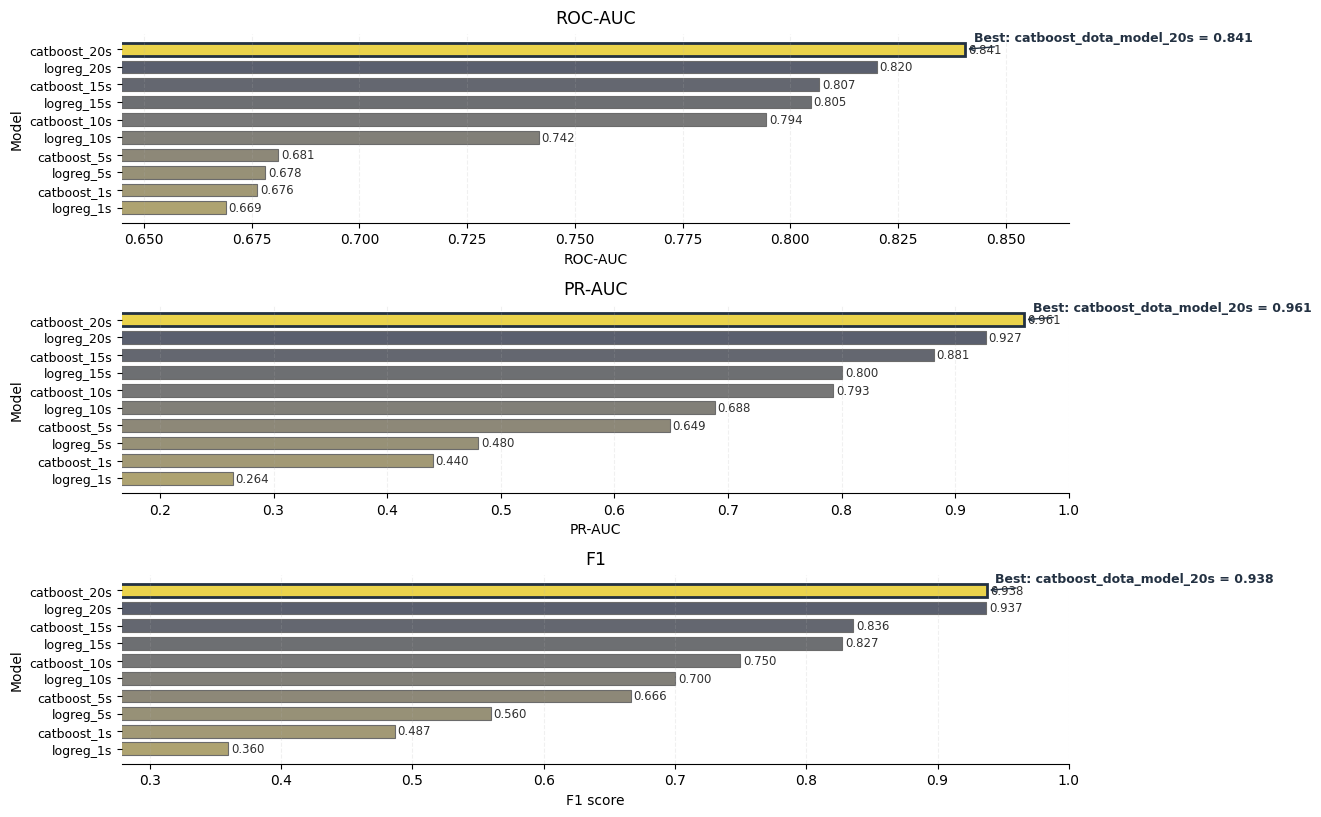

No baseline row detected in results_df.
Using metrics: ROC-AUC -> test_roc_auc, PR-AUC -> test_pr_auc, F1 -> test_f1
Rows plotted: 10 model(s)


In [20]:
# Three key comparison charts: ROC-AUC, PR-AUC and F1

if "results_df" not in globals():
    raise NameError("results_df is not available in the notebook context")

if not isinstance(results_df, pd.DataFrame):
    raise TypeError("results_df must be a pandas DataFrame")

model_col_candidates = ["model", "model_name", "name", "file"]
model_col = next((col for col in model_col_candidates if col in results_df.columns), None)
if model_col is None:
    raise KeyError("No model name column found. Expected one of: model, model_name, name, file")

metric_specs = [
    {
        "title": "ROC-AUC",
        "candidates": ["target_roc_auc", "test_roc_auc", "val_roc_auc", "roc_auc"],
        "xlabel": "ROC-AUC",
    },
    {
        "title": "PR-AUC",
        "candidates": ["target_pr_auc", "test_pr_auc", "val_pr_auc", "pr_auc"],
        "xlabel": "PR-AUC",
    },
    {
        "title": "F1",
        "candidates": ["target_f1", "test_f1", "val_f1", "f1"],
        "xlabel": "F1 score",
    },
]


def pick_metric_column(candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in results_df.columns:
            return candidate
    return None


def make_label(row: pd.Series) -> str:
    label = str(row[model_col])
    if "target_seconds" in row.index and pd.notna(row.get("target_seconds")):
        label = f"{label} ({int(row['target_seconds'])}s)"
    elif "target_col" in row.index and pd.notna(row.get("target_col")):
        target_text = str(row["target_col"]).replace("dead_in_", "")
        label = f"{label} ({target_text}s)"
    return label


def shorten_model_label(raw_label: str) -> str:
    lower_label = raw_label.lower()
    seconds_match = re.search(r"(\d+)s", raw_label)
    seconds_part = f"_{seconds_match.group(1)}s" if seconds_match else ""
    if "catboost" in lower_label:
        return f"catboost{seconds_part}"
    if "logreg" in lower_label:
        return f"logreg{seconds_part}"
    if "baseline" in lower_label:
        return f"baseline{seconds_part}"
    if "_" in raw_label:
        return raw_label.split("_")[0]
    return raw_label


plot_base = results_df.copy()
dup_subset = [model_col]
if "target_col" in plot_base.columns:
    dup_subset.append("target_col")
plot_base = plot_base.drop_duplicates(subset=dup_subset, keep="first").copy()
plot_base[model_col] = plot_base[model_col].astype(str)

baseline_mask = plot_base[model_col].str.contains("baseline", case=False, na=False)
baseline_df = plot_base.loc[baseline_mask].copy()
model_df = plot_base.loc[~baseline_mask].copy()

if model_df.empty and baseline_df.empty:
    raise ValueError("No rows available for plotting after cleaning")

baseline_summary: dict[str, float] = {}
for spec in metric_specs:
    metric_col = pick_metric_column(spec["candidates"])
    spec["metric_col"] = metric_col
    if metric_col is None:
        continue
    if not baseline_df.empty and metric_col in baseline_df.columns:
        baseline_values = pd.to_numeric(baseline_df[metric_col], errors="coerce").dropna()
        if not baseline_values.empty:
            baseline_summary[spec["title"]] = float(baseline_values.mean())

available_specs = [spec for spec in metric_specs if spec.get("metric_col") is not None]
if not available_specs:
    raise KeyError("No supported metric columns found. Expected ROC-AUC, PR-AUC or F1 columns.")

# Use ROC-AUC for the overall ordering when available, otherwise fall back to the first available metric.
ordering_spec = next((spec for spec in available_specs if spec["title"] == "ROC-AUC"), available_specs[0])
ordering_col = ordering_spec["metric_col"]
assert ordering_col is not None

ordered_df = model_df.copy()
ordered_df[ordering_col] = pd.to_numeric(ordered_df[ordering_col], errors="coerce")
ordered_df = ordered_df.dropna(subset=[model_col, ordering_col]).copy()
if ordered_df.empty:
    raise ValueError(f"No valid rows left after cleaning '{ordering_col}'")
ordered_df = ordered_df.sort_values(ordering_col, ascending=False).reset_index(drop=True)
ordered_df["label"] = ordered_df.apply(make_label, axis=1)
ordered_df["short_label"] = ordered_df["label"].map(shorten_model_label)

# Compact layout for a single slide: three stacked charts, shared ordering, short labels.
fig_size = (13.2, max(8.2, 0.34 * len(ordered_df) + 4.2))
shared_cmap = plt.get_cmap("cividis")

fig, axes = plt.subplots(len(available_specs), 1, figsize=fig_size, sharey=True)
if len(available_specs) == 1:
    axes = [axes]

for axis, spec in zip(axes, available_specs):
    metric_col = spec["metric_col"]
    assert metric_col is not None

    metric_df = ordered_df.copy()
    metric_df[metric_col] = pd.to_numeric(metric_df[metric_col], errors="coerce")
    metric_df = metric_df.dropna(subset=[model_col, metric_col]).copy()
    metric_df = metric_df.sort_values(metric_col, ascending=False).reset_index(drop=True)
    metric_df["label"] = metric_df.apply(make_label, axis=1)
    metric_df["short_label"] = metric_df["label"].map(shorten_model_label)

    metric_min = float(metric_df[metric_col].min())
    metric_max = float(metric_df[metric_col].max())
    metric_range = metric_max - metric_min
    padding = 0.04 if metric_range <= 0 else max(0.02, metric_range * 0.14)
    x_left = max(0.0, metric_min - padding)
    x_right = min(1.0, metric_max + padding)
    if x_right <= x_left:
        x_right = min(1.0, x_left + 0.08)

    color_values = np.linspace(0.30, 0.70, len(metric_df)) if len(metric_df) > 1 else np.array([0.5])
    bar_colors = [shared_cmap(value) for value in color_values]

    y_positions = np.arange(len(metric_df))
    bars = axis.barh(
        y_positions,
        metric_df[metric_col].to_numpy(),
        color=bar_colors,
        edgecolor="#6b6b6b",
        linewidth=0.8,
        height=0.72,
    )

    best_idx = int(metric_df[metric_col].idxmax())
    bars[best_idx].set_color(shared_cmap(0.92))
    bars[best_idx].set_edgecolor("#233142")
    bars[best_idx].set_linewidth(2.0)

    axis.bar_label(
        bars,
        labels=[f"{value:.3f}" for value in metric_df[metric_col]],
        padding=2,
        fontsize=8.5,
        color="#303030",
    )

    axis.annotate(
        f"Best: {metric_df.loc[best_idx, model_col]} = {metric_df.loc[best_idx, metric_col]:.3f}",
        xy=(metric_df.loc[best_idx, metric_col], best_idx),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="#233142",
        arrowprops=dict(arrowstyle="->", color="#233142", lw=1.0),
    )

    axis_baseline = baseline_summary.get(spec["title"])
    if axis_baseline is not None:
        axis.axvline(axis_baseline, color="#444444", linestyle="--", linewidth=1.2)
        axis.text(
            axis_baseline,
            1.01,
            f"Baseline {axis_baseline:.3f}",
            transform=axis.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#444444",
        )

    axis.set_yticks(y_positions)
    axis.set_yticklabels(metric_df["short_label"], fontsize=9)
    axis.invert_yaxis()
    axis.set_xlim(x_left, x_right)
    axis.set_xlabel(spec["xlabel"], fontsize=10)
    axis.set_ylabel("Model", fontsize=10)
    axis.set_title(f"{spec['title']}", fontsize=12.5, pad=8)
    axis.grid(axis="x", linestyle="--", alpha=0.18)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)

    if spec["title"] in baseline_summary:
        print(f"{spec['title']} baseline: {baseline_summary[spec['title']]:.3f}")

plt.tight_layout(pad=0.8, h_pad=1.0)
plt.show()

if baseline_df.empty:
    print("No baseline row detected in results_df.")
else:
    print(f"Baseline rows detected: {len(baseline_df)}")

print("Using metrics:", ", ".join(f"{spec['title']} -> {spec['metric_col']}" for spec in available_specs))
print(f"Rows plotted: {len(ordered_df)} model(s)")


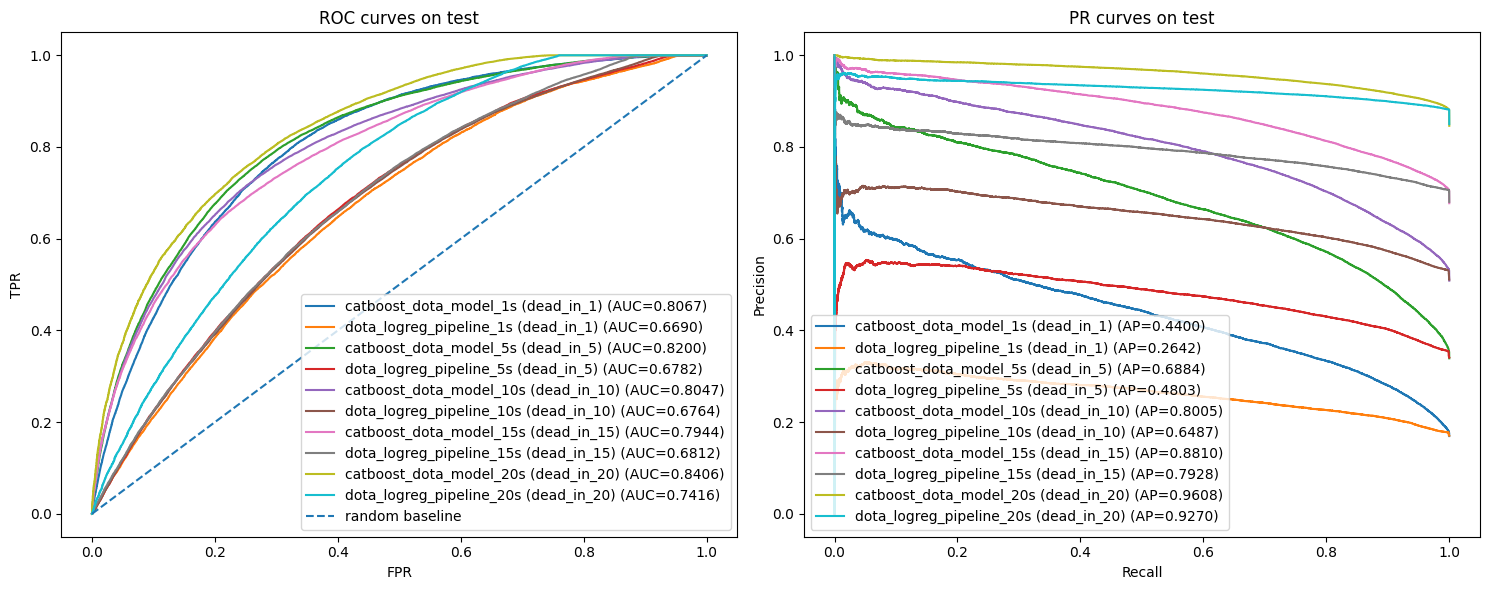

In [12]:
# Combined comparison curves

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for model_id, info in details.items():
    y_true = info["y_test"]
    y_proba = info["test_proba"]
    label = info.get("display_name", model_id)

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.4f})")

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    axes[1].plot(recall, precision, label=f"{label} (AP={pr_auc:.4f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", label="random baseline")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curves on test")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR curves on test")
axes[1].legend()

plt.tight_layout()
plt.show()


catboost_dota_model_1s (dead_in_1)
threshold: 0.245
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.365229,0.806717,0.44001,0.115257,0.772622,0.394239,0.635141,0.486501,0.245


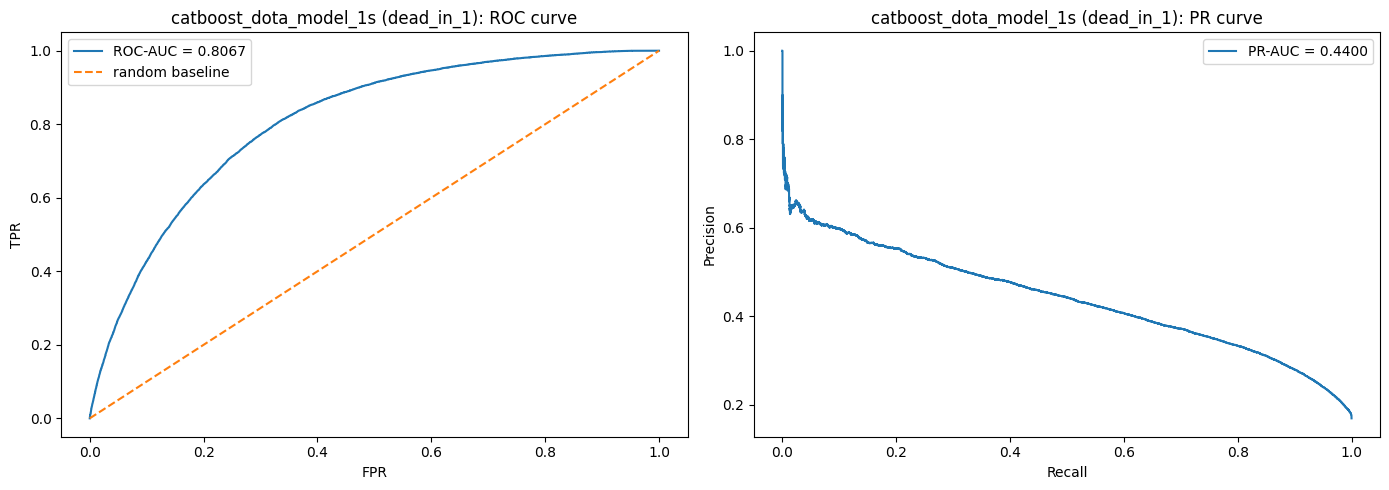

dota_logreg_pipeline_1s (dead_in_1)
threshold: 0.520301
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.649152,0.668971,0.264175,0.232079,0.612006,0.250136,0.639926,0.35968,0.520301


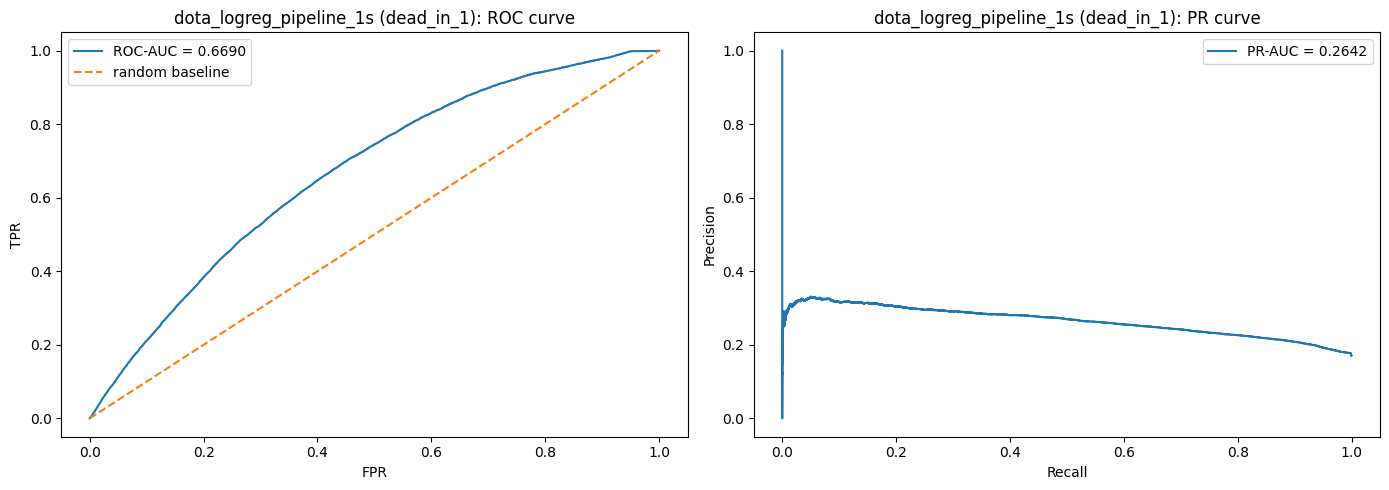

catboost_dota_model_5s (dead_in_5)
threshold: 0.335
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.484114,0.820007,0.688413,0.160161,0.740943,0.591663,0.762101,0.666153,0.335


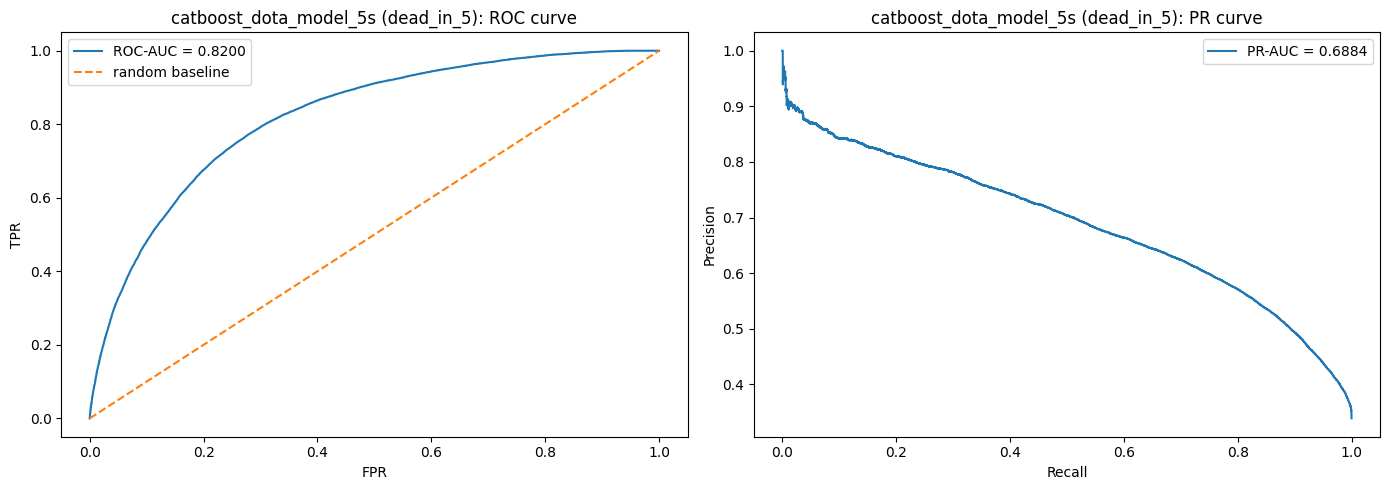

dota_logreg_pipeline_5s (dead_in_5)
threshold: 0.459512
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.642284,0.678216,0.480331,0.227761,0.561835,0.425461,0.817896,0.559747,0.459512


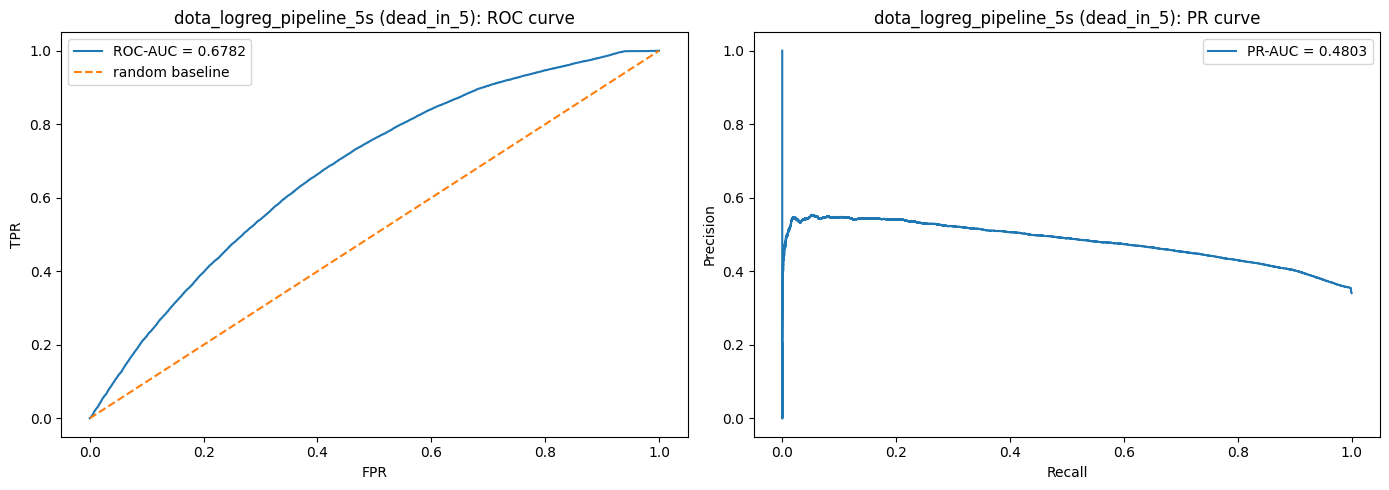

catboost_dota_model_10s (dead_in_10)
threshold: 0.375
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.534041,0.804698,0.800492,0.18001,0.716835,0.680983,0.833591,0.749599,0.375


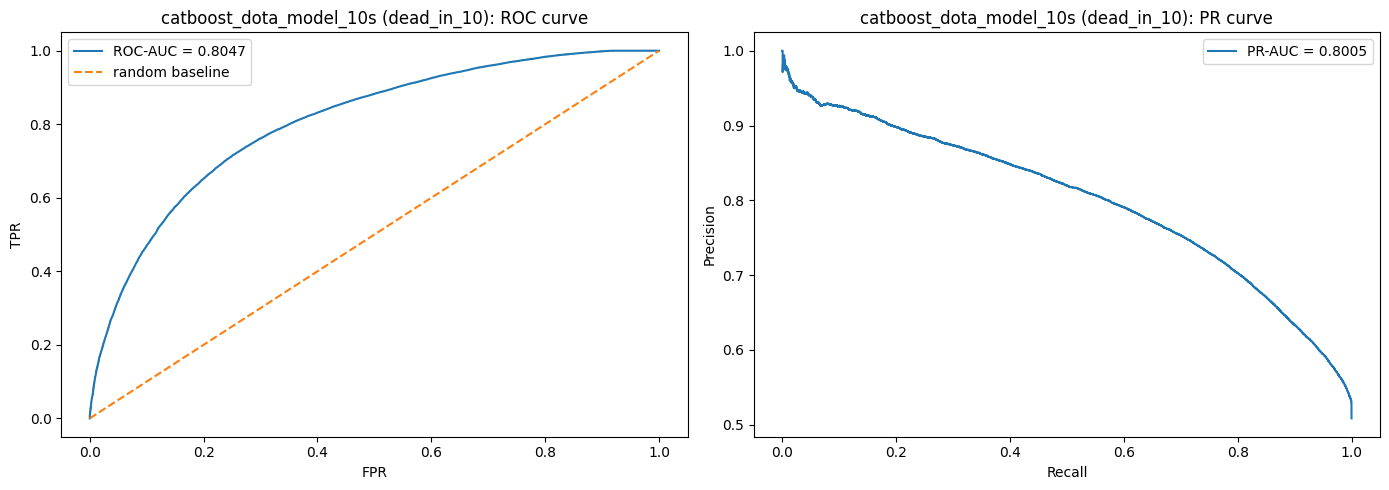

dota_logreg_pipeline_10s (dead_in_10)
threshold: 0.411738
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.638251,0.676372,0.64875,0.225037,0.6026,0.569532,0.908066,0.700018,0.411738


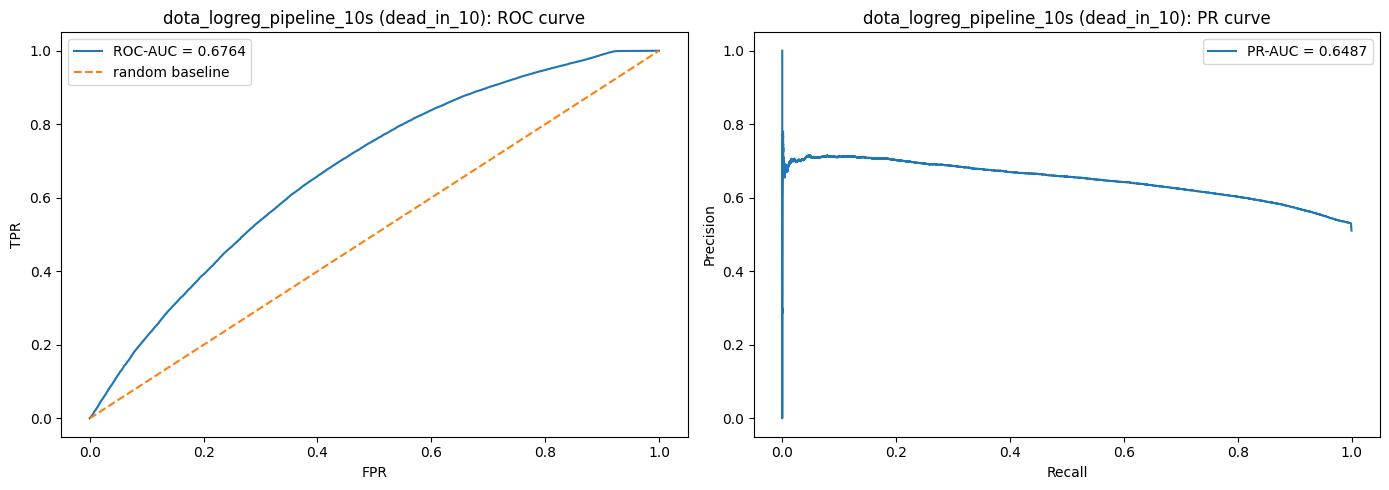

catboost_dota_model_15s (dead_in_15)
threshold: 0.41
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.490437,0.79444,0.881044,0.163349,0.744507,0.740373,0.959181,0.835692,0.41


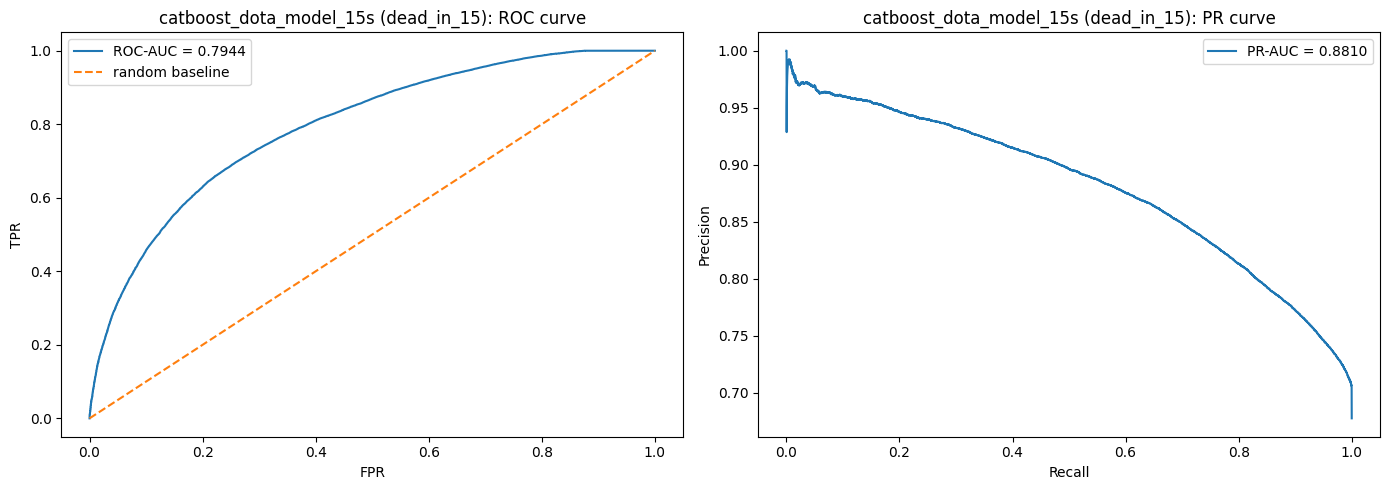

dota_logreg_pipeline_15s (dead_in_15)
threshold: 0.014846
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.623889,0.681177,0.792759,0.217992,0.716118,0.705718,0.999476,0.827294,0.014846


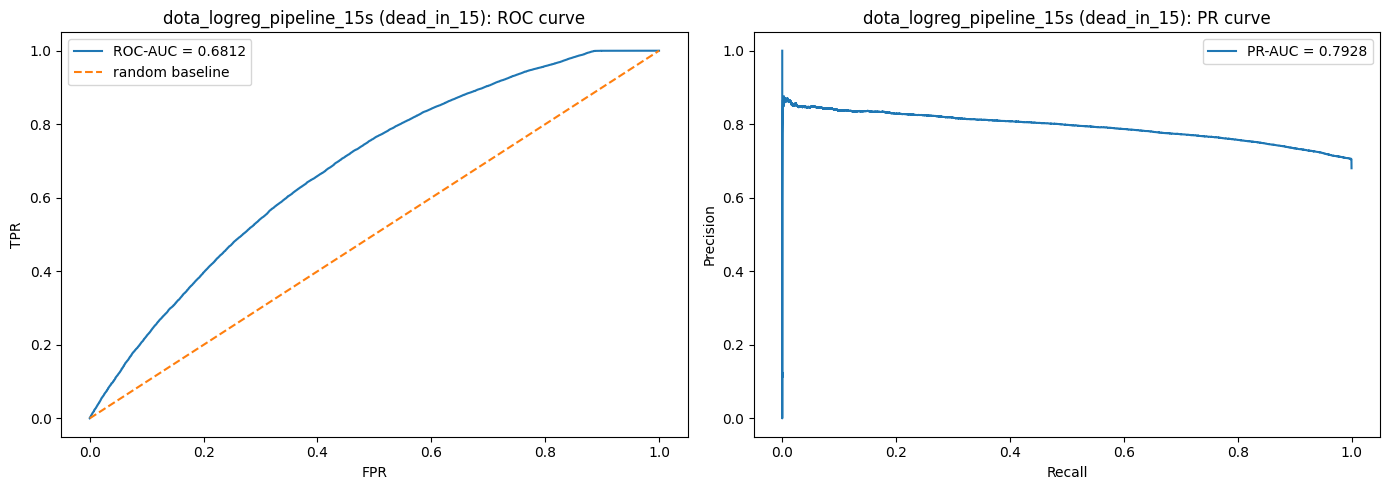

catboost_dota_model_20s (dead_in_20)
threshold: 0.475
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.294405,0.840575,0.960836,0.087297,0.888071,0.886396,0.995278,0.937686,0.475


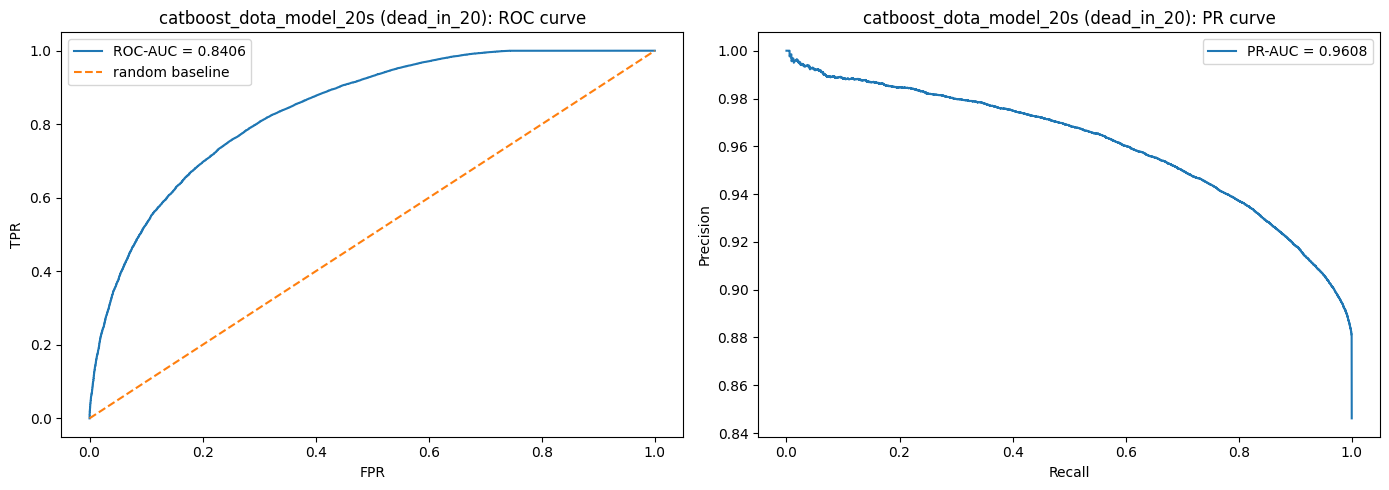

dota_logreg_pipeline_20s (dead_in_20)
threshold: 0.012666
test metrics at threshold:


,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1,threshold
0,0.548939,0.74161,0.926999,0.18364,0.885758,0.881508,0.999987,0.937017,0.012666


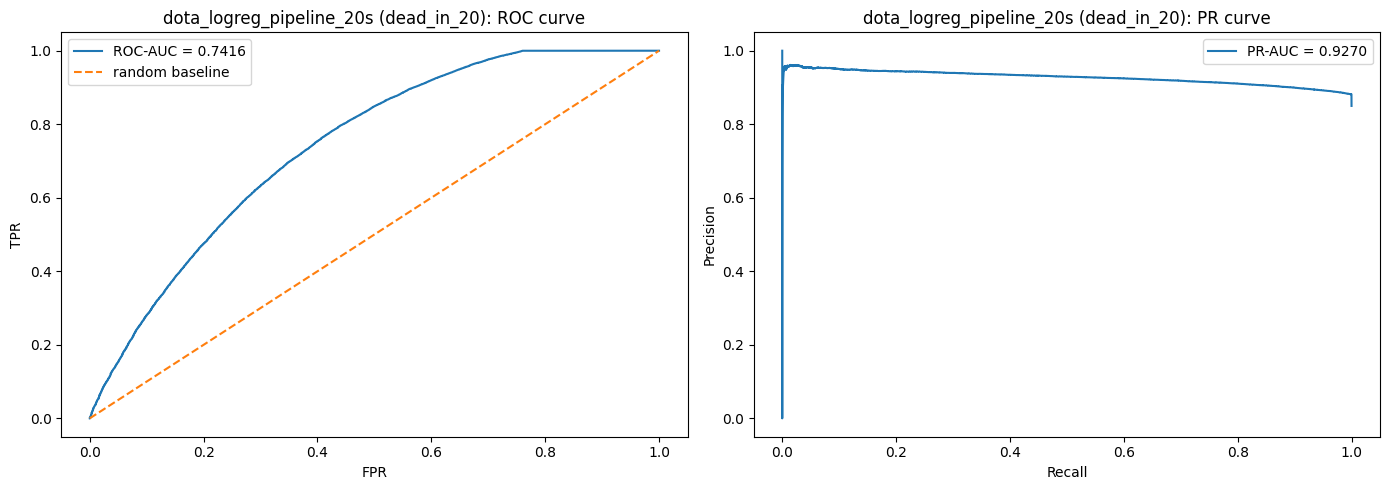

In [13]:
# Per-model detailed plots and metrics

for model_id, info in details.items():
    label = info.get("display_name", model_id)
    print("=" * 100)
    print(label)
    print("threshold:", round(info["threshold"], 6))
    print("test metrics at threshold:")
    display(
        pd.DataFrame(
            [{
                **evaluate_probabilities(info["y_test"], info["test_proba"], threshold=info["threshold"]),
                "threshold": info["threshold"],
            }]
        )
    )
    plot_roc_pr_curves(info["y_test"], info["test_proba"], title_prefix=label)


In [14]:
from time import perf_counter

XMIN = -9400
XMAX = 8000
YMIN = -8500
YMAX = 8500
BENCHMARK_CELLS = 32


def get_candidate_squares(square: int | None, cells: int, full_map: bool, interval: int) -> list[int]:
    if not isinstance(square, int) or square < 0 or square >= cells * cells:
        return list(range(cells * cells)) if full_map else []

    if full_map:
        return list(range(cells * cells))

    radius = max(0, (interval - 1) // 2)
    center_row = square // cells
    center_col = square % cells
    squares: list[int] = []
    for row in range(max(0, center_row - radius), min(cells, center_row + radius + 1)):
        for col in range(max(0, center_col - radius), min(cells, center_col + radius + 1)):
            squares.append(row * cells + col)
    return squares



def euclidean_distance(x1: float, y1: float, x2: float, y2: float) -> int:
    return int(np.hypot(x1 - x2, y1 - y2))



def cell_center(col: int, row: int, cells: int) -> tuple[float, float]:
    cell_width = (XMAX - XMIN) / cells
    cell_height = (YMAX - YMIN) / cells
    cx = XMIN + (col + 0.5) * cell_width
    cy = YMIN + (row + 0.5) * cell_height
    return cx, cy



def recalculate_distance_features(
    base_features: dict[str, object],
    x: float,
    y: float,
    square: int,
    tower_positions: list[dict[str, object]],
    is_radiant: bool,
    distance_fn,
) -> dict[str, object]:
    features = dict(base_features)
    features["x"] = int(x)
    features["y"] = int(y)
    features["square"] = square

    for idx in range(1, 6):
        enemy_x = features.get(f"enemy_{idx}_last_seen_x")
        enemy_y = features.get(f"enemy_{idx}_last_seen_y")
        if isinstance(enemy_x, (int, float)) and isinstance(enemy_y, (int, float)):
            features[f"enemy_{idx}_last_seen_distance"] = distance_fn(x, y, float(enemy_x), float(enemy_y))
        else:
            features[f"enemy_{idx}_last_seen_distance"] = int(1_000_000)

    allied_towers: list[tuple[float, float]] = []
    enemy_towers: list[tuple[float, float]] = []
    for tower in tower_positions:
        tower_x = tower.get("x")
        tower_y = tower.get("y")
        tower_team = tower.get("team")
        if not isinstance(tower_x, (int, float)) or not isinstance(tower_y, (int, float)):
            continue

        if (is_radiant and tower_team == 2) or (not is_radiant and tower_team == 3):
            allied_towers.append((float(tower_x), float(tower_y)))
        else:
            enemy_towers.append((float(tower_x), float(tower_y)))

    if allied_towers:
        features["nearest_ally_tower_distance"] = min(distance_fn(x, y, tx, ty) for tx, ty in allied_towers)
    if enemy_towers:
        features["nearest_enemy_tower_distance"] = min(distance_fn(x, y, tx, ty) for tx, ty in enemy_towers)

    return features



def predict_batch(model, model_path: Path, features: list[dict[str, object]]) -> np.ndarray:
    frame = pd.DataFrame(features)
    if model_path.suffix.lower() == ".cbm":
        for column in categorical_cols:
            if column in frame.columns:
                frame[column] = frame[column].astype("string")
        pool = Pool(frame, cat_features=[column for column in categorical_cols if column in frame.columns])
        return np.asarray(model.predict_proba(pool))[:, 1]
    return np.asarray(model.predict_proba(frame))[:, 1]



def build_heatmap_for_item(
    model,
    model_path: Path,
    base_features: dict[str, object],
    square: int | None,
    *,
    cells: int = BENCHMARK_CELLS,
    full_map: bool = False,
    interval: int = 1,
    tower_positions: list[dict[str, object]] | None = None,
    is_radiant: bool = False,
) -> tuple[list[list[float]], dict[str, float], int]:
    tower_positions = tower_positions or []
    candidate_squares = get_candidate_squares(square, cells=cells, full_map=full_map, interval=interval)

    t0 = perf_counter()
    grid_features: list[dict[str, object]] = []
    grid_squares: list[int] = []
    for candidate_square in candidate_squares:
        row = candidate_square // cells
        col = candidate_square % cells
        cx, cy = cell_center(col, row, cells)
        grid_features.append(
            recalculate_distance_features(
                base_features=base_features,
                x=cx,
                y=cy,
                square=candidate_square,
                tower_positions=tower_positions,
                is_radiant=is_radiant,
                distance_fn=euclidean_distance,
            )
        )
        grid_squares.append(candidate_square)
    build_elapsed = perf_counter() - t0

    t1 = perf_counter()
    grid_preds = predict_batch(model, model_path, grid_features) if grid_features else np.asarray([], dtype=float)
    predict_elapsed = perf_counter() - t1

    t2 = perf_counter()
    heatmap = [[0.0 for _ in range(cells)] for _ in range(cells)]
    for sq, pred in zip(grid_squares, grid_preds, strict=False):
        if not isinstance(sq, int):
            continue
        if sq < 0 or sq >= cells * cells:
            continue
        r = sq // cells
        c = sq % cells
        heatmap[r][c] = float(pred)
    fill_elapsed = perf_counter() - t2

    timings = {
        "build_ms": build_elapsed * 1000.0,
        "predict_ms": predict_elapsed * 1000.0,
        "fill_ms": fill_elapsed * 1000.0,
        "total_ms": (build_elapsed + predict_elapsed + fill_elapsed) * 1000.0,
    }
    return heatmap, timings, len(grid_squares)


benchmark_model_path = model_files[0]
benchmark_model = load_model_artifact(benchmark_model_path)

benchmark_row = df.iloc[0]
benchmark_features = benchmark_row[feature_cols].to_dict()
benchmark_square = int(benchmark_row["square"]) if "square" in benchmark_row else 0
benchmark_features["square"] = benchmark_square
benchmark_features["is_radiant"] = bool(benchmark_row.get("is_radiant", False))

benchmark_cases = [
    {"label": "1 cell", "full_map": False, "interval": 1, "square": benchmark_square},
    {"label": "32x32", "full_map": True, "interval": 1, "square": benchmark_square},
]

timing_rows = []
for case in benchmark_cases:
    _, timings, candidate_count = build_heatmap_for_item(
        benchmark_model,
        benchmark_model_path,
        benchmark_features,
        case["square"],
        cells=BENCHMARK_CELLS,
        full_map=case["full_map"],
        interval=case["interval"],
        tower_positions=[],
        is_radiant=bool(benchmark_features.get("is_radiant", False)),
    )
    timing_rows.append(
        {
            "case": case["label"],
            "model": benchmark_model_path.name,
            "candidates": candidate_count,
            **timings,
            "per_cell_ms": timings["total_ms"] / max(candidate_count, 1),
        }
    )

timing_df = pd.DataFrame(timing_rows)
display(
    timing_df.style.format(
        {
            "build_ms": "{:.3f}",
            "predict_ms": "{:.3f}",
            "fill_ms": "{:.3f}",
            "total_ms": "{:.3f}",
            "per_cell_ms": "{:.3f}",
        }
    )
)

print(f"Benchmark model: {benchmark_model_path}")
print(f"Base square: {benchmark_square}")

,case,model,candidates,build_ms,predict_ms,fill_ms,total_ms,per_cell_ms
0,1 cell,catboost_dota_model_1s.cbm,1,0.129,15.586,0.066,15.782,15.782
1,32x32,catboost_dota_model_1s.cbm,1024,25.218,22.254,0.220,47.691,0.047


Benchmark model: artifacts/boosting/catboost_dota_model_1s.cbm
Base square: 186
